<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Spoofed_Traffic_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found exi

In [1]:
pip show sionna


Name: sionna
Version: 2.0.1
Summary: Sionna - A hardware-accelerated differentiable open-source library for research on communication systems
Home-page: 
Author: 
Author-email: The Sionna contributors <sionna@nvidia.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: h5py, importlib-resources, matplotlib, numpy, scipy, sionna-rt, torch
Required-by: 


In [15]:
import tensorflow as tf
import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation area (meters)
AREA_X = 1000
AREA_Y = 1000

print("Simulation Area:", AREA_X, "x", AREA_Y, "meters")

Simulation Area: 1000 x 1000 meters


In [17]:
bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

print(bs_positions)

[[250 250]
 [750 250]
 [500 750]]


In [18]:
num_users = 30

user_positions = np.random.rand(num_users,2)

user_positions[:,0] *= AREA_X
user_positions[:,1] *= AREA_Y

print(user_positions)

[[ 94.11345103 548.53562032]
 [131.397781   310.72378724]
 [425.62842218  31.27739595]
 [916.46616849 174.80020386]
 [818.50420492 518.72016536]
 [563.43399107 855.78625563]
 [151.79248303   2.3929066 ]
 [897.72151099 910.73606048]
 [523.8307985  366.24635651]
 [990.77894511 373.75347538]
 [ 87.99020335 867.36692454]
 [355.64610512 206.85760331]
 [535.10822235 960.38679209]
 [564.31262419 955.24276228]
 [971.12161508 120.14384414]
 [101.60917462 727.91108948]
 [280.93836775 860.1449546 ]
 [247.30528969 644.2944988 ]
 [103.5898604  582.51873405]
 [239.87601382 223.82161685]
 [868.27474828 906.56331495]
 [ 65.87433705 328.35038941]
 [699.07266524 741.13078844]
 [799.0928418  248.27204619]
 [195.20044719 436.13059731]
 [318.56609285 776.4683592 ]
 [564.1911743  470.01306704]
 [ 78.44017405  15.21098398]
 [414.42535346 685.25821901]
 [549.70233478 237.25456007]]


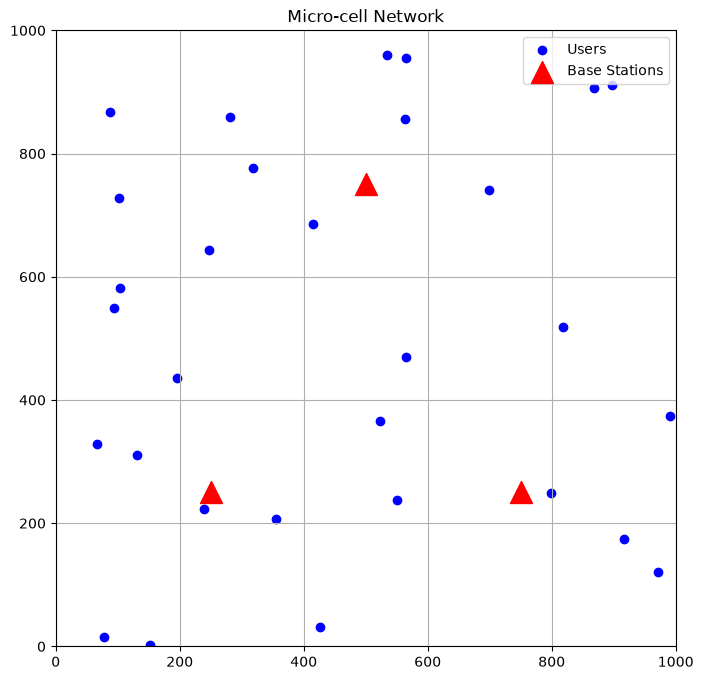

In [19]:
plt.figure(figsize=(8,8))

# Users
plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c='blue',
    label='Users'
)

# Base Stations
plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    c='red',
    s=250,
    marker='^',
    label='Base Stations'
)

plt.xlim(0,AREA_X)
plt.ylim(0,AREA_Y)

plt.grid(True)
plt.legend()

plt.title("Micro-cell Network")

plt.savefig("figures_network_layout_1.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
import tensorflow as tf
import sionna
import numpy as np
import matplotlib.pyplot as plt


# Distance matrix
distance_matrix = np.zeros((len(user_positions), len(bs_positions)))

for i, user in enumerate(user_positions):

    for j, bs in enumerate(bs_positions):

        distance = np.linalg.norm(user-bs)

        distance_matrix[i,j] = distance

print(distance_matrix)

[[336.78499484 720.63214036 453.13550613]
 [133.24362907 621.57548511 573.43804107]
 [280.50832465 391.22435765 722.56024881]
 [670.69528333 182.66361047 710.14003899]
 [628.81440687 277.31453868 393.61820393]
 [682.06880465 633.86423089 123.34748925]
 [266.37189997 647.42683452 824.72106859]
 [925.26498767 677.04784648 428.97375379]
 [297.48364931 254.29455973 384.4928684 ]
 [751.04485098 270.72019333 618.40554675]
 [638.27039233 905.2065457  428.40059233]
 [114.11558141 396.70676928 561.99796267]
 [765.46462546 742.177789   213.29601394]
 [772.11383841 729.27851695 215.08301908]
 [732.72027743 256.43203753 786.55855044]
 [500.41867122 805.48722639 399.00271893]
 [610.92884055 769.60748468 245.19361686]
 [394.30370687 638.88193241 273.91288689]
 [363.32442454 726.92143803 430.33820795]
 [ 28.06782572 510.79525157 586.96522817]
 [901.85312047 667.13139832 400.17291489]
 [200.10258189 688.5976374  605.1888014 ]
 [665.48907581 493.76415907 199.27014066]
 [549.09556066  49.12324236 584.11

In [21]:
assignments = np.argmin(distance_matrix, axis=1)

print(assignments)

[0 0 0 1 1 2 0 2 1 1 2 0 2 2 1 2 2 2 0 0 2 0 2 1 0 2 2 0 2 1]


In [22]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments==bs)

    print(f"BS {bs+1} has {count} users")

BS 1 has 10 users
BS 2 has 7 users
BS 3 has 13 users


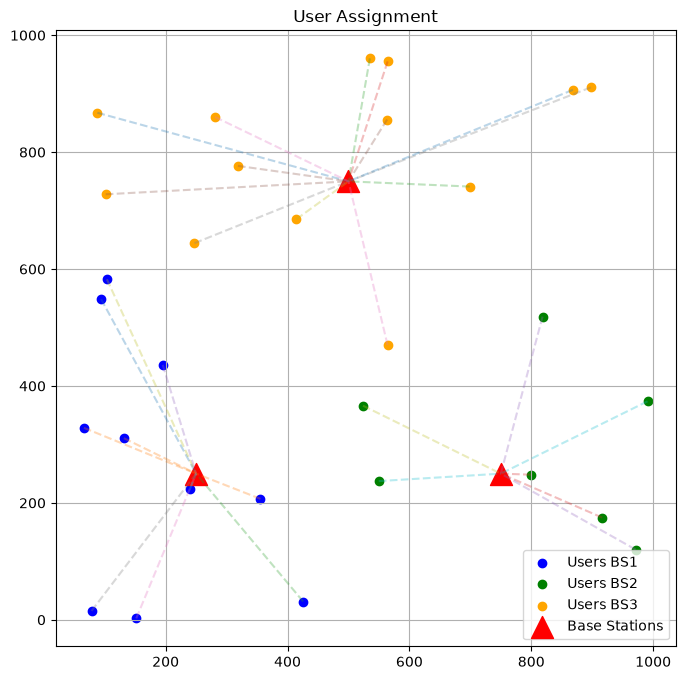

In [23]:
plt.figure(figsize=(8,8))

colors=['blue','green','orange']

# Draw users

for bs in range(3):

    idx = assignments==bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users BS{bs+1}'
    )

# Draw Base Stations

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=250,
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs=assignments[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3
    )

plt.grid()

plt.legend()

plt.title("User Assignment")

plt.savefig("figures_network_layout_2.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
import pandas as pd

results = pd.DataFrame({
    "User": range(1, len(assignments)+1),
    "Assigned_BS": assignments
})

results.to_csv("user_assignment.csv", index=False)

In [25]:
# -------------------------------
# Network Parameters
# -------------------------------

frequency = 3500      # MHz (5G frequency)
tx_power = 30         # dBm (micro-cell transmit power)

print("Frequency:", frequency, "MHz")
print("Transmit Power:", tx_power, "dBm")

Frequency: 3500 MHz
Transmit Power: 30 dBm


In [26]:
distance_matrix
print(distance_matrix)

[[336.78499484 720.63214036 453.13550613]
 [133.24362907 621.57548511 573.43804107]
 [280.50832465 391.22435765 722.56024881]
 [670.69528333 182.66361047 710.14003899]
 [628.81440687 277.31453868 393.61820393]
 [682.06880465 633.86423089 123.34748925]
 [266.37189997 647.42683452 824.72106859]
 [925.26498767 677.04784648 428.97375379]
 [297.48364931 254.29455973 384.4928684 ]
 [751.04485098 270.72019333 618.40554675]
 [638.27039233 905.2065457  428.40059233]
 [114.11558141 396.70676928 561.99796267]
 [765.46462546 742.177789   213.29601394]
 [772.11383841 729.27851695 215.08301908]
 [732.72027743 256.43203753 786.55855044]
 [500.41867122 805.48722639 399.00271893]
 [610.92884055 769.60748468 245.19361686]
 [394.30370687 638.88193241 273.91288689]
 [363.32442454 726.92143803 430.33820795]
 [ 28.06782572 510.79525157 586.96522817]
 [901.85312047 667.13139832 400.17291489]
 [200.10258189 688.5976374  605.1888014 ]
 [665.48907581 493.76415907 199.27014066]
 [549.09556066  49.12324236 584.11

In [27]:
distance_km = distance_matrix / 1000

# Avoid log10(0)
distance_km[distance_km < 0.001] = 0.001

import numpy as np

path_loss = 32.44 \
            + 20*np.log10(frequency) \
            + 20*np.log10(distance_km)

print(path_loss)

[[ 93.86841556 100.47563344  96.44592275]
 [ 85.81428994  99.19123844  98.49109089]
 [ 92.28027597  95.16987861 100.4988422 ]
 [ 99.85186593  88.55440164 100.34824088]
 [ 99.29181055  92.18081366  95.22286439]
 [ 99.99792463  99.36128579  85.14396716]
 [ 91.83112906  99.54517481 101.64750267]
 [102.64668346  99.93374811  95.96997531]
 [ 92.7906229   91.42810227  95.01912666]
 [100.83467835  91.97177392  99.14682841]
 [ 99.42145487 102.4563146   95.95836214]
 [ 84.46825983  95.29075311  98.31605571]
 [100.99986339 100.73151995  89.90101568]
 [101.07498761 100.57922929  89.97348337]
 [100.6201251   91.50080655 101.23598202]
 [ 97.30803099 101.44253404  95.34087799]
 [ 99.04117344 101.04674654  91.11154409]
 [ 95.23797809  99.42977302  92.07361019]
 [ 94.52725277 100.55111043  95.99755903]
 [ 72.28553631  97.48629791  98.69360838]
 [102.42407713  99.80558851  95.3663147 ]
 [ 89.34641473 100.08067145  98.95917855]
 [ 99.7841795   97.19175214  89.31020543]
 [ 98.11431954  77.14710138  98.65

In [28]:
received_power = tx_power - path_loss

print(received_power)

[[-63.86841556 -70.47563344 -66.44592275]
 [-55.81428994 -69.19123844 -68.49109089]
 [-62.28027597 -65.16987861 -70.4988422 ]
 [-69.85186593 -58.55440164 -70.34824088]
 [-69.29181055 -62.18081366 -65.22286439]
 [-69.99792463 -69.36128579 -55.14396716]
 [-61.83112906 -69.54517481 -71.64750267]
 [-72.64668346 -69.93374811 -65.96997531]
 [-62.7906229  -61.42810227 -65.01912666]
 [-70.83467835 -61.97177392 -69.14682841]
 [-69.42145487 -72.4563146  -65.95836214]
 [-54.46825983 -65.29075311 -68.31605571]
 [-70.99986339 -70.73151995 -59.90101568]
 [-71.07498761 -70.57922929 -59.97348337]
 [-70.6201251  -61.50080655 -71.23598202]
 [-67.30803099 -71.44253404 -65.34087799]
 [-69.04117344 -71.04674654 -61.11154409]
 [-65.23797809 -69.42977302 -62.07361019]
 [-64.52725277 -70.55111043 -65.99755903]
 [-42.28553631 -67.48629791 -68.69360838]
 [-72.42407713 -69.80558851 -65.3663147 ]
 [-59.34641473 -70.08067145 -68.95917855]
 [-69.7841795  -67.19175214 -59.31020543]
 [-68.11431954 -47.14710138 -68.65

In [29]:
assignments_signal = np.argmax(received_power, axis=1)

print(assignments_signal)


[0 0 0 1 1 2 0 2 1 1 2 0 2 2 1 2 2 2 0 0 2 0 2 1 0 2 2 0 2 1]


In [30]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments_signal == bs)

    print(f"BS {bs+1}: {count} users")

BS 1: 10 users
BS 2: 7 users
BS 3: 13 users


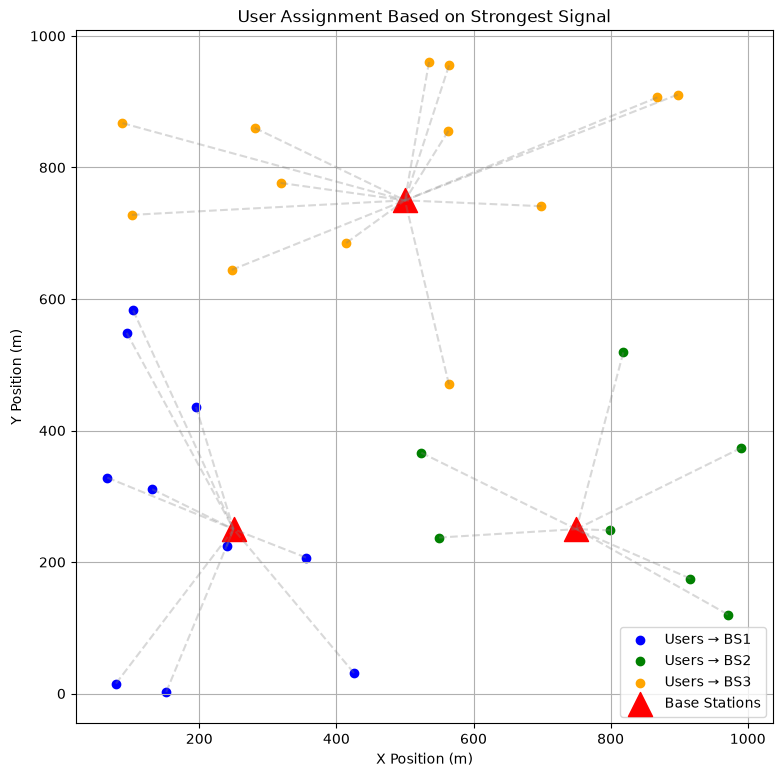

In [31]:
plt.figure(figsize=(9,9))

colors = ['blue','green','orange']

for bs in range(3):

    idx = assignments_signal == bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users → BS{bs+1}'
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    s=300,
    color='red',
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs = assignments_signal[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3,
        color='gray'
    )

plt.title("User Assignment Based on Strongest Signal")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step4_user_assignment_signal.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [32]:
import pandas as pd

results = pd.DataFrame({
    "User": np.arange(1, len(user_positions)+1),
    "Assigned_BS": assignments_signal + 1,
    "Best_RSRP_dBm": np.max(received_power, axis=1)
})

print(results.head())

results.to_csv("step4_user_assignment.csv", index=False)

   User  Assigned_BS  Best_RSRP_dBm
0     1            1     -63.868416
1     2            1     -55.814290
2     3            1     -62.280276
3     4            2     -58.554402
4     5            2     -62.180814


In [33]:
#STEP 5 - SINR Calculation
# Convert dBm to mW

received_power_mW = 10 ** (received_power / 10)

print(received_power_mW)

[[4.10353785e-07 8.96265451e-08 2.26677140e-07]
 [2.62162763e-06 1.20469236e-07 1.41543820e-07]
 [5.91524044e-07 3.04097002e-07 8.91488572e-08]
 [1.03469752e-07 1.39495384e-06 9.22945193e-08]
 [1.17711514e-07 6.05227473e-07 3.00409430e-07]
 [1.00047799e-07 1.15843433e-07 3.05916769e-06]
 [6.55974707e-07 1.11040784e-07 6.84305031e-08]
 [5.43665349e-08 1.01537201e-07 2.52931237e-07]
 [5.25941827e-07 7.19763423e-07 3.14838137e-07]
 [8.25148596e-08 6.35071478e-07 1.21707449e-07]
 [1.14249554e-07 5.68026425e-08 2.53608489e-07]
 [3.57416022e-06 2.95749956e-07 1.47365027e-07]
 [7.94353220e-08 8.44983065e-08 1.02305370e-06]
 [7.80730667e-08 8.75139065e-08 1.00612436e-06]
 [8.66936904e-08 7.07814320e-07 7.52318598e-08]
 [1.85864694e-07 7.17375592e-08 2.92356128e-07]
 [1.24704652e-07 7.85824104e-08 7.74186495e-07]
 [2.99365805e-07 1.14030938e-07 6.20353135e-07]
 [3.52593842e-07 8.80823630e-08 2.51329865e-07]
 [5.90808002e-05 1.78389878e-07 1.35094965e-07]
 [5.72258546e-08 1.04578197e-07 2.906487

In [34]:
# Thermal Noise (Assume a simple fixed thermal noise power)
noise_dBm = -100

noise_mW = 10 ** (noise_dBm / 10)

print("Noise Power (mW):", noise_mW)

Noise Power (mW): 1e-10


In [35]:
# Calculate SINR
sinr = []

for i in range(len(user_positions)):

    serving_bs = assignments_signal[i]

    signal = received_power_mW[i, serving_bs]

    interference = np.sum(received_power_mW[i]) - signal

    sinr_linear = signal / (interference + noise_mW)

    sinr.append(sinr_linear)

sinr = np.array(sinr)

# Convert SINR to dB
sinr_dB = 10 * np.log10(sinr)

print(sinr_dB)

[ 1.12916911 10.00082352  1.7719782   8.52604616  1.60512856 11.51167162
  5.62650199  2.09867469 -0.67544231  4.92506822  1.70781309  9.06559583
  7.9496554   7.83363299  6.4033584   0.54793986  5.80522267  1.76166888
  0.16419302 22.75091306  2.54110814  7.1251819   5.97536226 18.2156172
  5.13291229  7.16911323 -1.92007511  5.45025092 10.3937167   2.22189661]


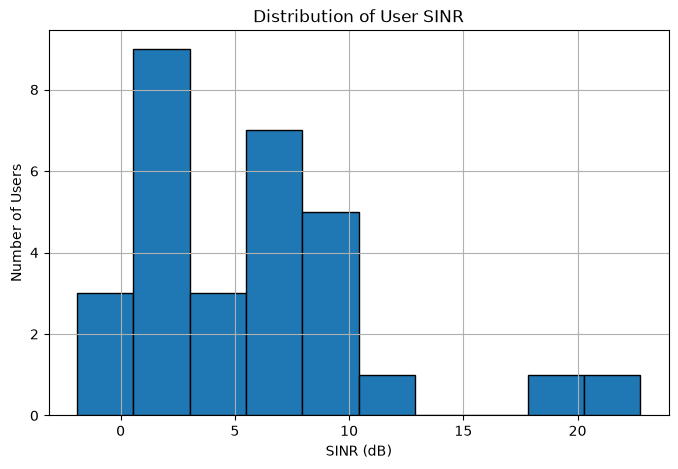

In [36]:
# Plot SINR Distribution
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=10,
         edgecolor='black')

plt.xlabel("SINR (dB)")
plt.ylabel("Number of Users")
plt.title("Distribution of User SINR")

plt.grid(True)

plt.savefig("figures_step5_sinr_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

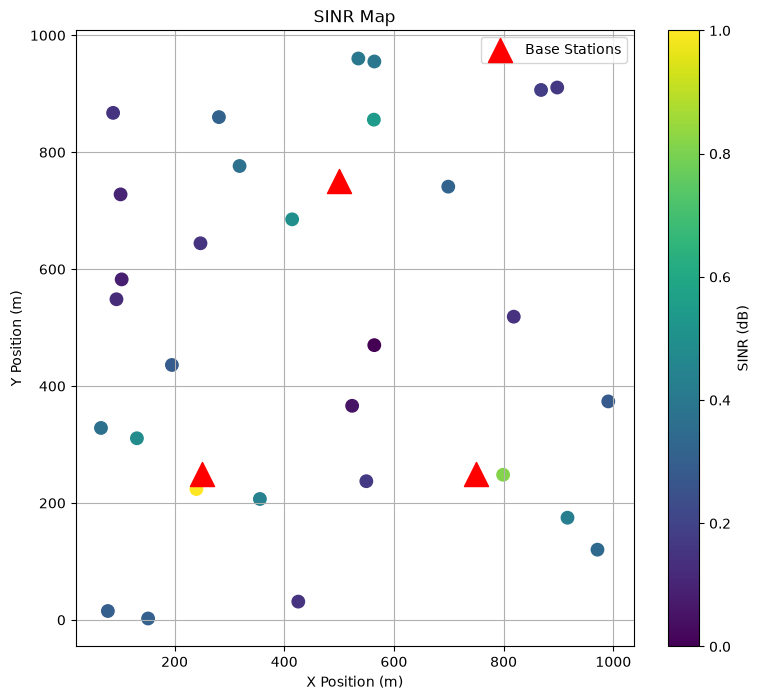

In [37]:
# Network Visualization
plt.figure(figsize=(9,8))

plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c=sinr_dB,
    cmap='viridis',
    s=80
)

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=300,
    label='Base Stations'
)

plt.colorbar(label="SINR (dB)")

plt.title("SINR Map")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step5_sinr_map.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [38]:
# Statistics
print("Average SINR :", np.mean(sinr_dB))

print("Maximum SINR :", np.max(sinr_dB))

print("Minimum SINR :", np.min(sinr_dB))

Average SINR : 5.760489903579211
Maximum SINR : 22.750913059026168
Minimum SINR : -1.9200751064233488


In [39]:
# Save Results
results["SINR_dB"] = sinr_dB

results.to_csv(
    "results_step5_sinr_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB
0     1            1     -63.868416   1.129169
1     2            1     -55.814290  10.000824
2     3            1     -62.280276   1.771978
3     4            2     -58.554402   8.526046
4     5            2     -62.180814   1.605129


In [40]:
#====================================================
# STEP 6 - QoS Analysis
#====================================================

# Spectral Efficiency (bits/s/Hz)

spectral_efficiency = np.log2(1 + sinr)

print(spectral_efficiency)


[1.19970759 3.45968032 1.32413477 3.02184274 1.29110117 3.92252026
 2.21816256 1.39029087 0.89216914 2.03850105 1.31137043 3.18017465
 2.85536256 2.82220822 2.42452851 1.0938796  2.26497735 1.32207884
 1.02752962 7.56532691 1.48294719 2.62256441 2.30991855 6.07269231
 2.09104061 2.63479839 0.71604848 2.17239835 3.5788095  1.4157454 ]


In [41]:
# Bandwidth per user

bandwidth = 20e6      # 20 MHz

throughput = bandwidth * spectral_efficiency

throughput_Mbps = throughput / 1e6

print(throughput_Mbps)

[ 23.99415186  69.19360639  26.48269535  60.43685473  25.8220235
  78.45040516  44.36325123  27.80581741  17.84338279  40.77002108
  26.22740866  63.60349297  57.1072512   56.44416445  48.49057011
  21.87759196  45.29954699  26.44157679  20.55059243 151.30653822
  29.65894382  52.45128816  46.19837092 121.45384623  41.82081216
  52.69596789  14.32096964  43.44796705  71.57619003  28.3149081 ]


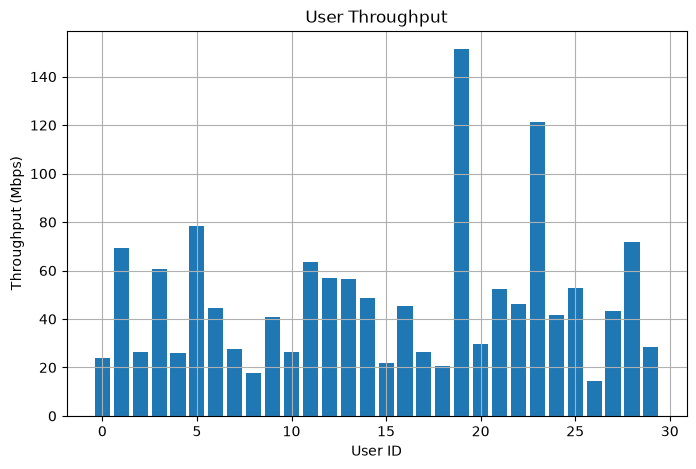

In [42]:
# Plot Throughput

plt.figure(figsize=(8,5))

plt.bar(range(len(throughput_Mbps)),
        throughput_Mbps)

plt.xlabel("User ID")
plt.ylabel("Throughput (Mbps)")
plt.title("User Throughput")

plt.grid(True)

plt.savefig(
    "figures_step6_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
# Average Throughput
print("Average Throughput:")

print(np.mean(throughput_Mbps),"Mbps")

Average Throughput:
47.8150069092813 Mbps


In [44]:
# Packet Error Rate (PER)
packet_error_rate = np.exp(-sinr)

print(packet_error_rate)

[2.73369445e-01 4.53139143e-05 2.22277918e-01 8.07115804e-04
 2.35240310e-01 7.06185210e-07 2.59131574e-02 1.97638583e-01
 4.24873190e-01 4.46819919e-02 2.27234730e-01 3.14612669e-04
 1.95600047e-03 2.30553867e-03 1.26697856e-02 3.21591706e-01
 2.22265283e-02 2.23071878e-01 3.53974426e-01 1.50299946e-82
 1.66095621e-01 5.75067696e-03 1.90907599e-02 1.59617514e-29
 3.83671853e-02 5.45685307e-03 5.25882959e-01 2.99651152e-02
 1.75768164e-05 1.88628563e-01]


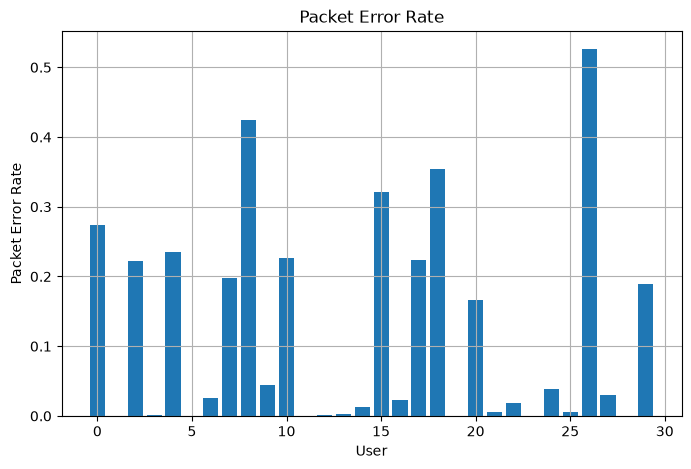

In [45]:
# Plot PER
plt.figure(figsize=(8,5))

plt.bar(range(len(packet_error_rate)),
        packet_error_rate)

plt.xlabel("User")

plt.ylabel("Packet Error Rate")

plt.title("Packet Error Rate")

plt.grid(True)

plt.savefig(
    "figures_step6_packet_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# Latency Model
latency = 100/(sinr+1)

print(latency)

[43.53635126  9.08934208 39.93886481 12.31217257 40.86390057  6.59483211
 21.49149038 38.14878804 53.88034003 24.34165129 40.29379422 11.03245182
 13.81816013 14.13938991 18.6270549  46.84998211 20.80529501 39.99582069
 49.05494154  0.52797052 35.77572253 16.23788449 20.16718258  1.48572168
 23.47113302 16.10077017 60.87625515 22.18415716  8.36895035 37.48160391]


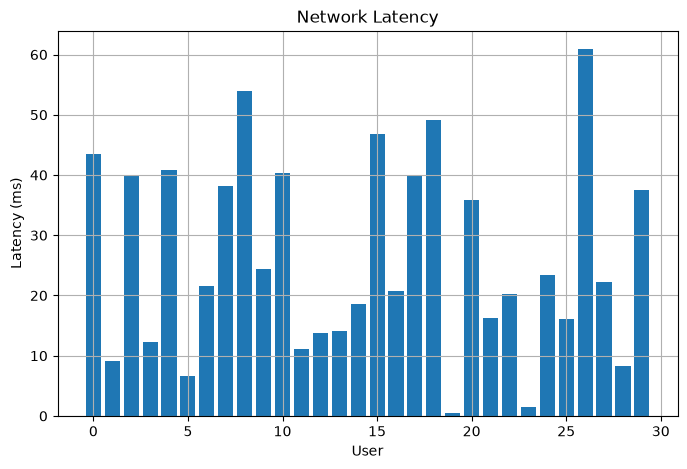

In [47]:
# Plot Latency
plt.figure(figsize=(8,5))

plt.bar(range(len(latency)),
        latency)

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Network Latency")

plt.grid(True)

plt.savefig(
    "figures_step6_latency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# QoS Summary
print("========== QoS SUMMARY ==========")

print("Average SINR:",
      np.mean(sinr_dB),
      "dB")

print("Average Throughput:",
      np.mean(throughput_Mbps),
      "Mbps")

print("Average Latency:",
      np.mean(latency),
      "ms")

print("Average PER:",
      np.mean(packet_error_rate))

========== QoS SUMMARY ==========
Average SINR: 5.760489903579211 dB
Average Throughput: 47.8150069092813 Mbps
Average Latency: 26.249732500848847 ms
Average PER: 0.11898160821004616


In [49]:
# Save Results
results["SINR_dB"] = sinr_dB
results["Spectral_Efficiency"] = spectral_efficiency
results["Throughput_Mbps"] = throughput_Mbps
results["Latency_ms"] = latency
results["PER"] = packet_error_rate

results.to_csv(
    "results_step6_qos_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB  Spectral_Efficiency  \
0     1            1     -63.868416   1.129169             1.199708   
1     2            1     -55.814290  10.000824             3.459680   
2     3            1     -62.280276   1.771978             1.324135   
3     4            2     -58.554402   8.526046             3.021843   
4     5            2     -62.180814   1.605129             1.291101   

   Throughput_Mbps  Latency_ms       PER  
0        23.994152   43.536351  0.273369  
1        69.193606    9.089342  0.000045  
2        26.482695   39.938865  0.222278  
3        60.436855   12.312173  0.000807  
4        25.822023   40.863901  0.235240  


In [50]:
# Step 7
# Save normal network results

normal_throughput = throughput_Mbps.copy()
normal_latency = latency.copy()
normal_per = packet_error_rate.copy()
normal_assignments = assignments_signal.copy()

In [51]:
# Number of users connected to each BS

cell_load = np.zeros(len(bs_positions), dtype=int)

for bs in assignments_signal:
    cell_load[bs] += 1

print("Current Cell Load")

for i, load in enumerate(cell_load):
    print(f"BS{i+1}: {load} users")

Current Cell Load
BS1: 10 users
BS2: 7 users
BS3: 13 users


In [52]:
#----------------------------------------
# Spoofed Traffic Attack
#----------------------------------------

target_bs = 1      # BS2 (index starts from 0)

spoofed_users = 20

print("Attack Target : BS", target_bs+1)
print("Fake Users :", spoofed_users)

Attack Target : BS 2
Fake Users : 20


In [53]:
# Increase Cell Load
attack_cell_load = cell_load.copy()

attack_cell_load[target_bs] += spoofed_users

print("Cell Load After Attack")

for i, load in enumerate(attack_cell_load):
    print(f"BS{i+1}: {load} users")

Cell Load After Attack
BS1: 10 users
BS2: 27 users
BS3: 13 users


In [54]:
# Available Bandwidth Per Cell
total_bandwidth = 20e6      #20 MHz

bandwidth_per_bs = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):
    bandwidth_per_bs[i] = total_bandwidth / attack_cell_load[i]

print(bandwidth_per_bs)

[2000000.          740740.74074074 1538461.53846154]


In [55]:
# Calculate New Throughput
attack_throughput = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    attack_bandwidth = bandwidth_per_bs[bs]

    attack_throughput[i] = (
        attack_bandwidth
        * spectral_efficiency[i]
        / 1e6
    )

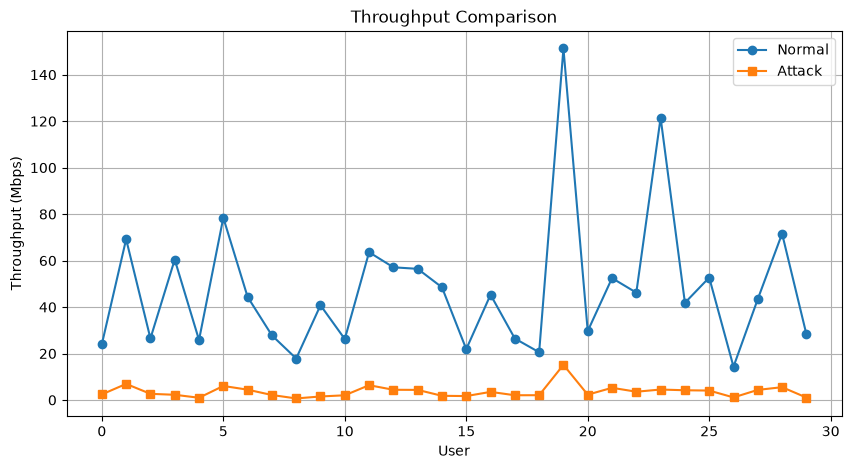

In [56]:
# Plot Throughput Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_throughput,
         marker='o',
         label="Normal")

plt.plot(attack_throughput,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Throughput (Mbps)")

plt.title("Throughput Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_throughput_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
# New Latency
attack_latency = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    load_factor = attack_cell_load[bs] / cell_load[bs]

    attack_latency[i] = latency[i] * load_factor

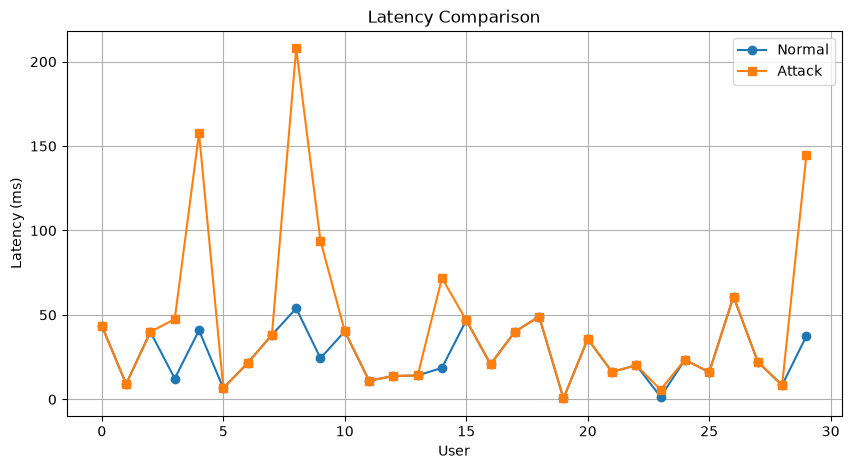

In [58]:
# Plot Latency Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_latency,
         marker='o',
         label="Normal")

plt.plot(attack_latency,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Latency Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
# QoS Comparison
print("========== NORMAL ==========")

print("Average Throughput:",
      np.mean(normal_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(normal_latency),
      "ms")

print("\n========== ATTACK ==========")

print("Average Throughput:",
      np.mean(attack_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(attack_latency),
      "ms")

========== NORMAL ==========
Average Throughput: 47.8150069092813 Mbps
Average Latency: 26.249732500848847 ms

========== ATTACK ==========
Average Throughput: 3.635113932683299 Mbps
Average Latency: 44.2490129724647 ms


In [60]:
# Save Results
attack_results = results.copy()

attack_results["Attack_Throughput_Mbps"] = attack_throughput
attack_results["Attack_Latency_ms"] = attack_latency

attack_results.to_csv(
    "results_step7_attack_results.csv",
    index=False
)

In [61]:
# ====================================================
# STEP 7A - Legitimate Traffic Generation
# ====================================================

# Simulation Parameters
import numpy as np

simulation_time = 10          # seconds

packet_size = 1500            # Bytes

time_step = 1                 # second

# Legitimate Traffic
np.random.seed(42)

traffic_rate = np.random.randint(5,16,size=len(user_positions))

print(traffic_rate)

# Total Legitimate Packets
legitimate_packets = traffic_rate * simulation_time

print(legitimate_packets)

[11  8 15 12  9 11 14  7 11 15 15 12  9  8 12 12  7 10  9  6 12 10  6  9
  5 14 10 13  5 15]
[110  80 150 120  90 110 140  70 110 150 150 120  90  80 120 120  70 100
  90  60 120 100  60  90  50 140 100 130  50 150]


In [62]:
# Spoofed Traffic
attack_levels = {
    "Normal":0,
    "Low":50,
    "Medium":200,
    "High":500
}

target_bs = 1 # Suppose the attacker targets BS2

spoofed_packets = attack_levels["Medium"] * simulation_time

print(spoofed_packets)

2000


In [63]:
# Base Station Load
bs_packets = np.zeros(len(bs_positions))

for i,bs in enumerate(assignments_signal):

    bs_packets[bs] += legitimate_packets[i]

print(bs_packets)

# Inject Attack
attack_packets = bs_packets.copy()

attack_packets[target_bs] += spoofed_packets

print(attack_packets)

[1030.  830. 1260.]
[1030. 2830. 1260.]


In [64]:
# Queue Model
bs_capacity = 2000      # packets

queue = np.maximum(
    attack_packets-bs_capacity,
    0
)

print(queue)

[  0. 830.   0.]


In [65]:
# Queue Delay
queue_delay = queue / bs_capacity

print(queue_delay)

[0.    0.415 0.   ]


In [66]:
# User Latency
attack_latency = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    attack_latency[i] = latency[i] + queue_delay[bs]*1000

In [67]:
# Throughput Reduction
bs_capacity_Mbps = 1000

attack_throughput = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    load = attack_packets[bs]

    attack_throughput[i] = (
        throughput_Mbps[i]
        *
        bs_capacity
        /
        load
    )

In [68]:
# Packet Loss
packet_loss = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):

    if attack_packets[i] > bs_capacity:

        packet_loss[i] = (
            attack_packets[i]-bs_capacity
        ) / attack_packets[i]
packet_loss1 = packet_loss*100
print(packet_loss1, "%")

[ 0.         29.32862191  0.        ] %


In [69]:
# Visulaization --- do later Base Station Queue Length vs Attack Level
# Throughput vs Attack Level
# Latency vs Attack Level
# Packet Loss vs Attack Level
# Cell Load vs Attack Level
# User Assignment Map
# QoS Heat Map

In [70]:
# ====================================================
# STEP 8 - Impact Assessment
# ====================================================

attack_levels = {
    "Normal": 0,
    "Low": 50,
    "Medium": 200,
    "High": 500
}

bs_capacity = 2000          # packets
simulation_time = 10        # seconds
target_bs = 1               # BS2

# Create Lists to Store Results
average_throughput = []
average_latency = []
average_packet_loss = []
average_queue = []

# Run All Attack Scenarios
for attack_name, attack_rate in attack_levels.items():

    spoofed_packets = attack_rate * simulation_time

    attack_packets = bs_packets.copy()

    attack_packets[target_bs] += spoofed_packets

    queue = np.maximum(attack_packets-bs_capacity,0)

    queue_delay = queue/bs_capacity

    attack_latency = np.zeros(len(user_positions))

    attack_throughput = np.zeros(len(user_positions))

    for i,bs in enumerate(assignments_signal):

        attack_latency[i] = latency[i] + queue_delay[bs]*1000

        attack_throughput[i] = (
            throughput_Mbps[i]
            *
            bs_capacity
            /
            attack_packets[bs]
        )

    packet_loss = np.zeros(len(bs_positions))

    for bs in range(len(bs_positions)):

        if attack_packets[bs] > bs_capacity:

            packet_loss[bs] = (
                attack_packets[bs]-bs_capacity
            )/attack_packets[bs]

    average_throughput.append(np.mean(attack_throughput))

    average_latency.append(np.mean(attack_latency))

    average_packet_loss.append(np.mean(packet_loss))

    average_queue.append(np.mean(queue))

# Display Results
import pandas as pd

impact_results = pd.DataFrame({

    "Attack_Level": attack_levels.keys(),

    "Avg_Throughput_Mbps": average_throughput,

    "Avg_Latency_ms": average_latency,

    "Avg_Queue_Packets": average_queue,

    "Avg_Packet_Loss": average_packet_loss

})

print(impact_results)


  Attack_Level  Avg_Throughput_Mbps  Avg_Latency_ms  Avg_Queue_Packets  \
0       Normal            91.649613       26.249733           0.000000   
1          Low            81.288420       26.249733           0.000000   
2       Medium            72.172036      123.083066         276.666667   
3         High            68.012587      473.083066        1276.666667   

   Avg_Packet_Loss  
0         0.000000  
1         0.000000  
2         0.097762  
3         0.218982  


In [71]:
# Save Results
impact_results.to_csv(
    "results_step8_impact_assessment.csv",
    index=False
)

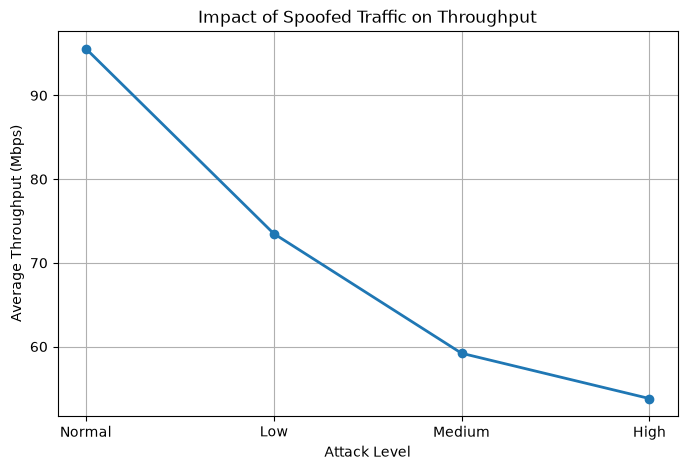

In [ ]:
# Throughput vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Throughput_Mbps"],
    marker='o',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Throughput (Mbps)")

plt.title("Impact of Spoofed Traffic on Throughput")

plt.grid(True)

plt.savefig(
    "figures_step8_throughput_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

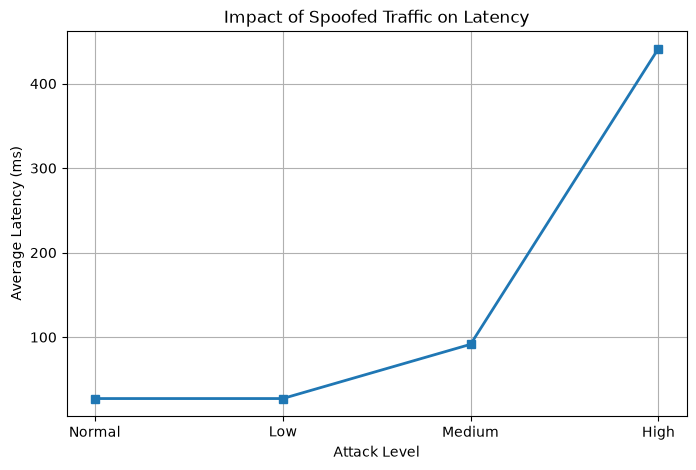

In [ ]:
#Latency vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Latency_ms"],
    marker='s',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Latency (ms)")

plt.title("Impact of Spoofed Traffic on Latency")

plt.grid(True)

plt.savefig(
    "figures_step8_latency_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

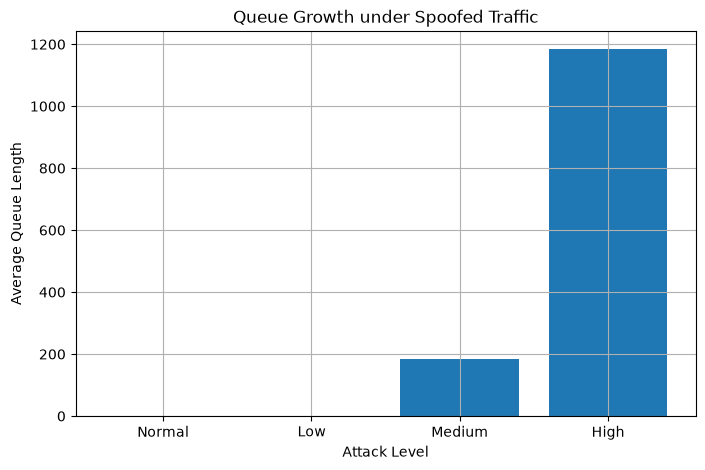

In [ ]:
# Queue Length
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Queue_Packets"]
)

plt.xlabel("Attack Level")

plt.ylabel("Average Queue Length")

plt.title("Queue Growth under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_queue_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

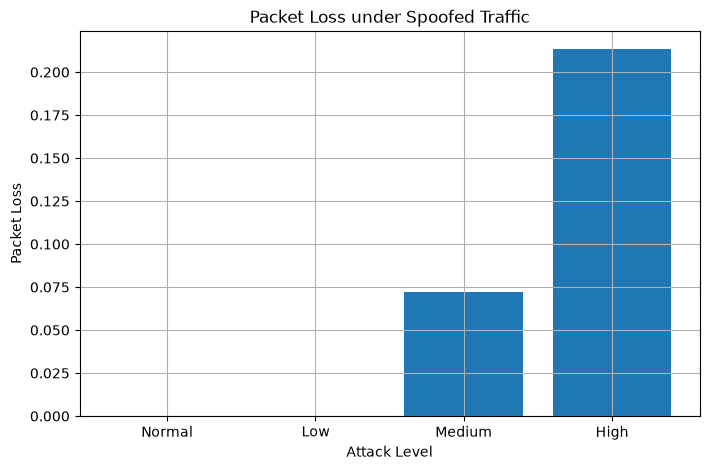

In [ ]:
# Packet Loss
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Packet_Loss"]
)

plt.xlabel("Attack Level")

plt.ylabel("Packet Loss")

plt.title("Packet Loss under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_packet_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

TensorFlow: 2.20.0
Sionna: 2.0.1
Modules Imported Successfully


In [ ]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([0 0 1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0], shape=(20,), dtype=int32)


In [ ]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[-1. -1.  1. -1.  1.  1. -1.  1. -1.  1.  1. -1. -1. -1.  1.  1.  1.  1.
  1. -1.], shape=(20,), dtype=float32)


In [ ]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: []
Length of BER: 0
[]


In [ ]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [ ]:
print(ber)
len(ber)

[np.float64(0.0748), np.float64(0.0379), np.float64(0.0101), np.float64(0.0018), np.float64(0.0002), np.float64(0.0001), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


11

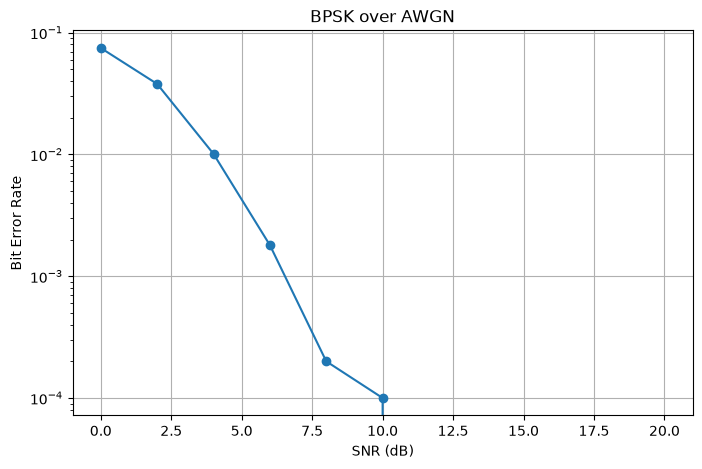

In [ ]:
SNR_dB = np.arange(0,21,2)
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import sionna

print(dir(sionna))
print("Sionna Version:", sionna.__version__)

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']
Sionna Version: 2.0.1


In [ ]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [ ]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']


In [ ]:
import pkgutil
import sionna.phy

print("Available PHY Packages\n")

for module in pkgutil.iter_modules(sionna.phy.__path__):
    print(module.name)

Available PHY Packages

block
channel
config
constants
fec
mapping
mimo
nr
object
ofdm
signal
utils


In [ ]:
import sionna.phy.channel

print(dir(sionna.phy.channel))

import sionna.phy.ofdm

print(dir(sionna.phy.ofdm))

import sionna.phy.channel as ch

print(dir(ch))

import sionna.phy.ofdm as ofdm

print(dir(ofdm))


['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [ ]:
# ======================================================
# STEP 10 - Sionna PHY Integration
# Small-Scale Fading
# ======================================================

import tensorflow as tf
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

num_users = len(user_positions)

In [ ]:
# Rayleigh fading coefficient

# Real part
real = tf.random.normal([num_users], dtype=tf.float32)

# Imaginary part
imag = tf.random.normal([num_users], dtype=tf.float32)

# Create complex channel coefficients
h = tf.complex(real, imag) / tf.cast(tf.sqrt(2.0), tf.complex64)

print(h[:10])

tf.Tensor(
[ 0.23155521+5.9555773e-02j -0.59582645-6.0875088e-01j
  0.22587374+2.6737338e-01j -0.9952895 -3.6743204e-03j
 -1.6886133 -3.4968692e-01j -0.7348592 +4.3686414e-01j
 -0.39408705-2.3392540e-01j  0.38163048-9.7869278e-04j
  1.2016801 -2.9962525e-01j  0.204309  -9.8090470e-01j], shape=(10,), dtype=complex64)


In [ ]:
# Channel Power Gain
channel_gain = tf.abs(h)**2

channel_gain = channel_gain.numpy()

print(channel_gain[:10])

[0.0571647  0.7255867  0.12250746 0.9906148  2.9736955  0.7308684
 0.2100257  0.14564277 1.5338103  1.0039163 ]


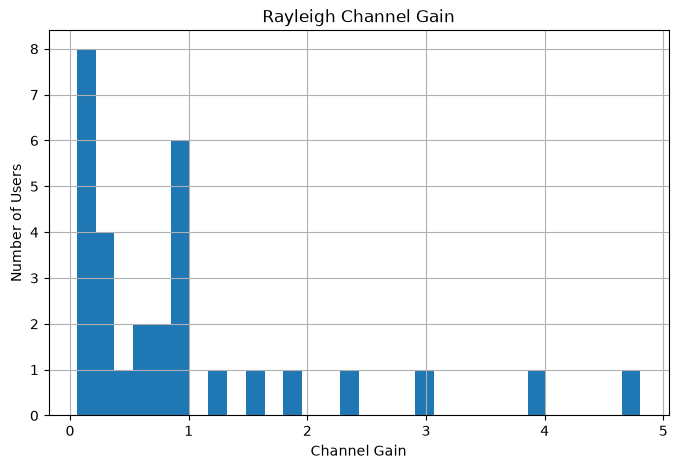

In [ ]:
# Plot the Fading Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(channel_gain,
         bins=30)

plt.xlabel("Channel Gain")

plt.ylabel("Number of Users")

plt.title("Rayleigh Channel Gain")

plt.grid(True)

plt.savefig(
    "figures_step10_channel_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
received_power
channel_gain = channel_gain.reshape(-1, 1)

received_power_fading = received_power + 10*np.log10(channel_gain)

print(received_power_fading[:10])

[[-80.59857215 -79.8351827  -61.40467891]
 [-66.99739134 -54.23781418 -68.63484481]
 [-81.10189092 -76.91152052 -75.60046516]
 [-66.85456907 -65.64424295 -56.80142134]
 [-53.17769331 -58.96939984 -62.71700325]
 [-68.98271743 -70.84420652 -57.86473627]
 [-68.75837552 -77.57317046 -78.14464841]
 [-71.00352562 -79.00763462 -80.19603123]
 [-69.04054944 -64.82678832 -62.55266967]
 [-61.96184051 -63.27101369 -69.59835223]]


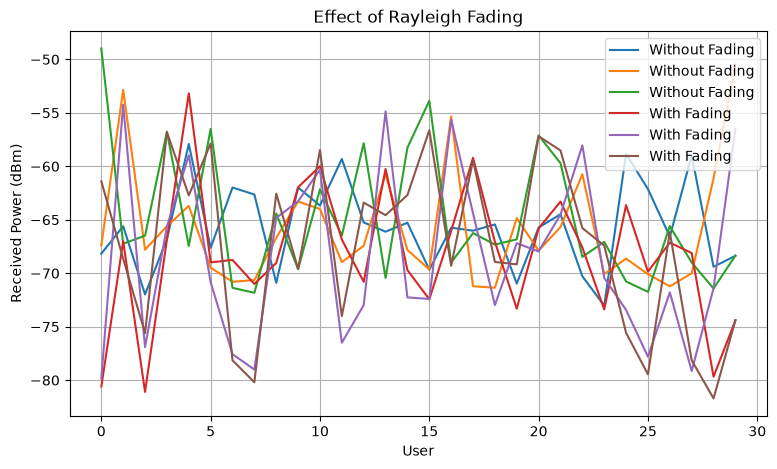

In [ ]:
# Plot the Difference
plt.figure(figsize=(9,5))

plt.plot(received_power,
         label="Without Fading")

plt.plot(received_power_fading,
         label="With Fading")

plt.xlabel("User")

plt.ylabel("Received Power (dBm)")

plt.title("Effect of Rayleigh Fading")

plt.legend()

plt.grid(True)

plt.savefig(
    "figures_step10_received_power_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Recalculate SINR
received_power_mW = 10**(received_power_fading/10)

noise_power = 1e-10

sinr = received_power_mW / noise_power

sinr_dB = 10*np.log10(sinr)

print(sinr_dB[:10])

[[19.40142785 20.1648173  38.59532109]
 [33.00260866 45.76218582 31.36515519]
 [18.89810908 23.08847948 24.39953484]
 [33.14543093 34.35575705 43.19857866]
 [46.82230669 41.03060016 37.28299675]
 [31.01728257 29.15579348 42.13526373]
 [31.24162448 22.42682954 21.85535159]
 [28.99647438 20.99236538 19.80396877]
 [30.95945056 35.17321168 37.44733033]
 [38.03815949 36.72898631 30.40164777]]


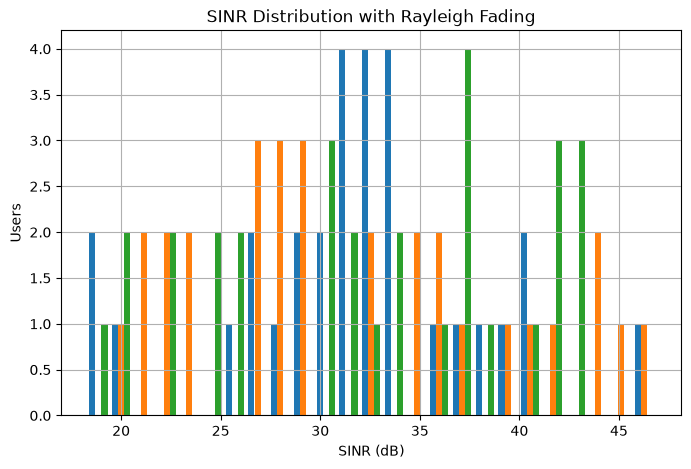

In [ ]:
# Compare SINR
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=25)

plt.xlabel("SINR (dB)")

plt.ylabel("Users")

plt.title("SINR Distribution with Rayleigh Fading")

plt.grid(True)

plt.savefig(
    "figures_step10_sinr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =====================================================
# STEP 11 - Beamforming
# =====================================================

beamforming_gain_dB = 6

print("Beamforming Gain:", beamforming_gain_dB, "dB")

received_power_beamforming = received_power_fading + beamforming_gain_dB

print(received_power_beamforming[:5])
print(received_power_fading.shape)

Beamforming Gain: 6 dB
[[-74.59857215 -73.8351827  -55.40467891]
 [-60.99739134 -48.23781418 -62.63484481]
 [-75.10189092 -70.91152052 -69.60046516]
 [-60.85456907 -59.64424295 -50.80142134]
 [-47.17769331 -52.96939984 -56.71700325]]
(30, 3)


In [ ]:
# Calculate New SINR
received_power_mW = 10 ** (received_power_beamforming / 10)
# Assume:
noise_power_mW = 1e-10

sinr_beam = received_power_mW / noise_power_mW

sinr_beam_dB = 10 * np.log10(sinr_beam)

In [ ]:
# Compare Average SINR
print("Average SINR without Beamforming:")

print(np.mean(sinr_dB))

print()

print("Average SINR with Beamforming:")

print(np.mean(sinr_beam_dB))

Average SINR without Beamforming:
31.96509381506488

Average SINR with Beamforming:
37.965093815064876


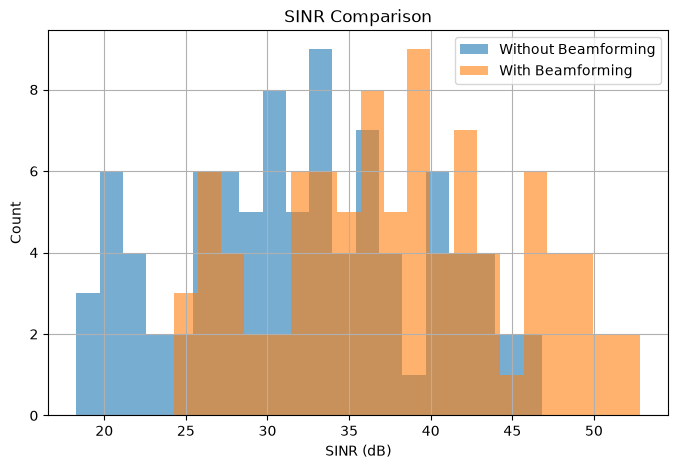

In [ ]:
# Plot the Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    sinr_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="Without Beamforming"
)

plt.hist(
    sinr_beam_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="With Beamforming"
)

plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.title("SINR Comparison")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_sinr_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Count Users Per Base Station
num_bs = received_power_beamforming.shape[1]

users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

BS 1: 10 users
BS 2: 7 users
BS 3: 13 users


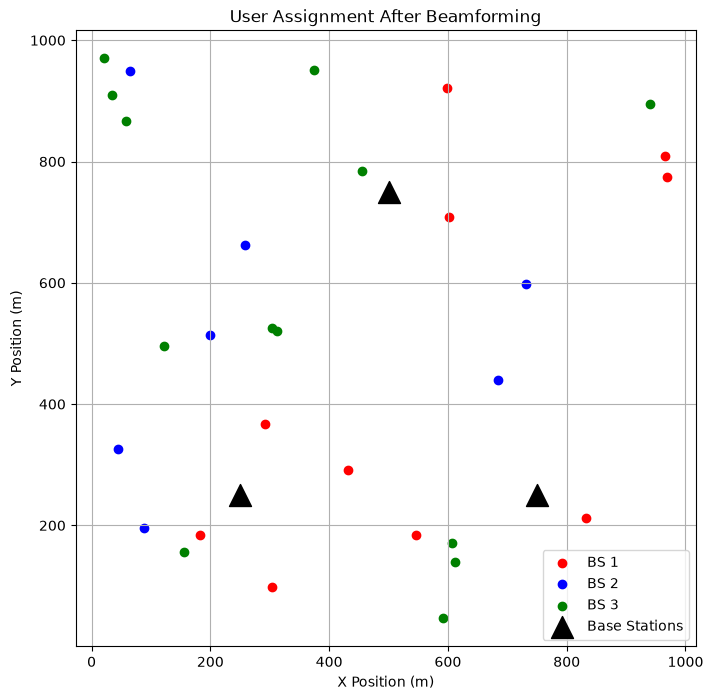

In [ ]:
# Visualize User Assignment
colors = ["red", "blue", "green"]

plt.figure(figsize=(8,8))

for bs in range(num_bs):

    users = user_positions[
        assignments_beamforming == bs
    ]

    plt.scatter(
        users[:,0],
        users[:,1],
        color=colors[bs],
        label=f"BS {bs+1}"
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker="^",
    s=250,
    color="black",
    label="Base Stations"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("User Assignment After Beamforming")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_user_assignment_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()